# 🚀 Making vLLM Fast

### *(in-container edition — run this from inside the vLLM image)*

## One GPU. One model. Seven steps. Several times the speed.

---

You're going to take an ordinary `vllm serve` command and make it **dramatically faster** — without
touching a line of Python, and without buying a single extra GPU.

Along the way you'll be able to answer the question every team eventually asks:

> ### *"How many users can this thing actually serve?"*

**New to vLLM? You're in the right place.** Every step says what it does in plain English first.
The deeper details are tucked into fold-out boxes you can ignore.

---

### 🧗 The climb

We're building a ladder. **Every step adds one thing and the number goes up.**

| # | Step | What it does |
|---|---|---|
| 1️⃣ | **Get it running** | the API, tool calling, reasoning |
| 2️⃣ | **Turn up the users** | 1 → 16 → 128 → 512, and find the wall |
| 3️⃣ | **FP8 weights** | shrink the model |
| 4️⃣ | **FP8 KV cache** | shrink the notes it takes |
| 5️⃣ | **AITER expert kernels** | AMD's fast MoE code |
| 6️⃣ | **AITER everywhere** | ...and the rest |
| 7️⃣ | **Speculative decoding** | guess several words at once |

Plus two things we'll **look at but not score**, because a throughput number would mislead you:
**context sizing** (it's about capacity, not speed) and **prefix caching** (it depends on your traffic,
not your server).

Plus one **trap** we'll walk into deliberately, because the mistake is more memorable than the rule.

---

### 🎬 Our setup

|  |  |
|---|---|
| **Model** | `Qwen/Qwen3-30B-A3B` |
| **GPU** | 1× AMD Instinct MI300X (192 GB) |
| **Rule** | change one thing, measure, repeat |

Our model is a **Mixture-of-Experts**. It stores ~30 billion parameters but uses only about **3
billion per word** — like a hospital with 128 specialists where each patient sees 8 of them.

Hold onto that. It explains our most interesting result.

---
# 🧰 Setup

*Quick housekeeping. Already prepared? Skim and move on.*

In [1]:
!rocm-smi --showproductname 2>/dev/null | grep -E "Card Series|GFX Version" | head -4
!echo && echo "NUMA balancing (we want 0):" && cat /proc/sys/kernel/numa_balancing

GPU[0]		: Card Series: 		N/A
GPU[0]		: GFX Version: 		gfx942

NUMA balancing (we want 0):
0


> ⚠️ If that printed `1`, run `sudo sh -c 'echo 0 > /proc/sys/kernel/numa_balancing'`.
> Otherwise Linux shuffles memory around underneath the GPU and you get a hang that looks
> exactly like a vLLM bug.

### Confirm the environment

You're already inside the vLLM container, so everything is installed. Let's confirm the versions.

In [2]:
%%bash
mkdir -p results logs
# python3 -c "import vllm, torch; print('vLLM ', vllm.__version__); print('torch', torch.__version__)"


### 🩺 Health check — boring, and it will save your day

vLLM **renames flags between releases**. Worse: set an environment variable it no longer recognises
and vLLM says nothing at all. It just quietly ignores you.

You'd run your benchmark, get a number, and believe something false.

So we ask the image directly. Everything should say `OK`.

In [3]:
%%bash
# Flag names drift between releases. Everything here should say OK.
vllm serve --help=all 2>/dev/null > /tmp/h.txt
vllm bench serve --help=all 2>/dev/null > /tmp/b.txt
echo "server flags:"
for f in --kv-cache-dtype --speculative-config --gpu-memory-utilization --cpu-offload-gb --kv-offloading-size \
         --moe-backend --linear-backend --attention-backend --reasoning-parser; do
  grep -q -- "$f" /tmp/h.txt && echo "  OK       $f" || echo "  MISSING  $f"
done
echo "benchmark flags:"
for f in --num-warmups --tokenizer prefix_repetition; do
  grep -q -- "$f" /tmp/b.txt && echo "  OK       $f" || echo "  MISSING  $f"
done


server flags:
  OK       --kv-cache-dtype
  OK       --speculative-config
  OK       --gpu-memory-utilization
  OK       --cpu-offload-gb
  OK       --kv-offloading-size
  OK       --moe-backend
  OK       --linear-backend
  OK       --attention-backend
  OK       --reasoning-parser
benchmark flags:
  OK       --num-warmups
  OK       --tokenizer
  OK       prefix_repetition


<details>
<summary>🔧 <b>If anything says MISSING</b></summary>

- **`--moe-backend` / `--linear-backend` / `--attention-backend`** — your image is older. It picks
  kernels with environment variables instead (`VLLM_ROCM_USE_AITER_MOE`, `VLLM_ROCM_USE_AITER_MHA`,
  `VLLM_USE_TRITON_FLASH_ATTN`). Use those in the AITER section and check the log to confirm they took effect.
- **`--num-warmups`** — drop the flag and run each benchmark twice, ignoring the first.
- `vllm serve --help` needs GPU devices attached, which is why this cell passes `--device` even though
  it never starts a server.

</details>

### Download the weights

~92 GB. **Do this before the audience arrives.** Cached already? Returns in seconds.

In [4]:
%%bash
# ~92 GB. Do this BEFORE the workshop. Cached already? Returns in seconds.
python3 -c "from huggingface_hub import snapshot_download as d; d('Qwen/Qwen3-30B-A3B'); d('Qwen/Qwen3-30B-A3B-FP8')" 2>&1 | tail -1
du -sh ~/.cache/huggingface/hub 2>/dev/null


Fetching 17 files: 100%|██████████| 17/17 [00:29<00:00,  1.73s/it]
754G	/root/.cache/huggingface/hub


---
## 🏃 How we start and stop servers

This notebook runs **inside the vLLM container**, so there's no `docker run` wrapper — we call
`vllm serve` directly.

Each step follows the same three moves:

```bash
# 1. start it in the background, logging to a file
nohup vllm serve Qwen/Qwen3-30B-A3B --served-model-name qwen --port 8000 \
    > logs/current.log 2>&1 &

# 2. wait until it actually answers
bash wait.sh

# 3. when done: keep the log under a step name, then stop it
cp logs/current.log logs/baseline.log
pkill -f 'vllm serve'
```

<details>
<summary>📝 <b>Why the log file matters</b></summary>

vLLM prints how it divided up your GPU at startup — weights, KV cache pool, maximum concurrency. We
compare those numbers between steps, so every server writes to `logs/current.log` and we copy it to a
named file before starting the next one.

</details>

**`--served-model-name qwen`** is a small trick worth knowing: later we swap to a different checkpoint
with a different Hugging Face name. Pinning the served name to `qwen` keeps **every other command in
this notebook identical**.


In [5]:
import os
# Running inside the container: no docker wrapper needed.
# Pin to one GPU (harmless on a single-GPU box).
os.environ.setdefault("HIP_VISIBLE_DEVICES", "0")
print("in-container mode · GPU", os.environ["HIP_VISIBLE_DEVICES"])


in-container mode · GPU 0


### Two small helpers

**`wait.sh`** holds the notebook until the server actually answers, so nothing fires too early.

**`scoreboard()`** is our ladder. We call it after every step and watch the number climb. 📈

In [6]:
%%writefile wait.sh
#!/bin/bash
echo "starting server — this takes a few minutes..."
for i in $(seq 1 300); do
    curl -sf localhost:8000/health > /dev/null && { echo "✅ ready in $((i*2))s"; exit 0; }
    pgrep -f "vllm serve" > /dev/null || {
        echo "❌ container died:"; tail -30 logs/current.log; exit 1; }
    sleep 2
done
echo "❌ not up after 10 min:"; tail -30 logs/current.log

Writing wait.sh


In [7]:
import json, glob

def scoreboard():
    rows = []
    for f in sorted(glob.glob("results/*.json")):
        d = json.load(open(f))
        rows.append((f.split("/")[-1][:-5].split("-", 1)[1],
                     d["total_token_throughput"], d["median_ttft_ms"], d["median_tpot_ms"]))
    if not rows:
        print("no results yet"); return rows
    top = max(r[1] for r in rows)
    # everything after the concurrency ramp is compared to the 128-user baseline
    base = next((r[1] for r in rows if r[0].startswith("512users")), rows[0][1])
    print(f"{'STEP':<16}{'TOTAL TOK/S':>13}  {'':<26}{'vs 512-user':>12}{'TPOT ms':>10}")
    print("─" * 80)
    for name, t, _, tpot in rows:
        bar = "█" * max(1, round(24 * t / top))
        print(f"{name:<16}{t:>13,.0f}  {bar:<26}{t/base:>11.2f}x{tpot:>10,.1f}")
    return rows

print("helpers loaded ✓")

helpers loaded ✓


---
---
# 1️⃣ First light — get it running

### 🎯 Goal
A working LLM API, and a look at what it can do.

This is the plainest possible command. No tuning. What everyone types on day one.

We do pass three extras, but they're **free** — they change how answers are *formatted*, not how fast
they arrive:

| Flag | What it gives you |
|---|---|
| `--enable-auto-tool-choice` | the model can call your functions |
| `--tool-call-parser hermes` | those calls arrive as clean JSON |
| `--reasoning-parser qwen3` | the model's "thinking" arrives in its own field |

> 📌 **Feature flags vs performance flags.** These three are feature flags — they never move a
> benchmark number. Everything else we add today is a performance flag. Keeping those apart in your
> head is genuinely useful.

In [8]:
%%bash
setsid nohup vllm serve Qwen/Qwen3-30B-A3B \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
    > logs/current.log 2>&1 &
echo "launched — watch logs/current.log"


launched — watch logs/current.log


In [9]:
!bash wait.sh

starting server — this takes a few minutes...
✅ ready in 140s


## 💬 Say hello

vLLM speaks the **OpenAI API**. Anything that already talks to OpenAI talks to this by changing one
URL. No rewrite.

It's plain HTTP — here it is with nothing but `curl`:

In [10]:
%%bash
curl -s localhost:8000/v1/chat/completions -H "Content-Type: application/json" \
  -d '{"model":"qwen","messages":[{"role":"user","content":"Say hello in one short sentence."}],"max_tokens":40,"chat_template_kwargs":{"enable_thinking":false}}' \
| head -c 400

{"id":"chatcmpl-977b13dc5ca254b8","object":"chat.completion","created":1789640680,"model":"qwen","choices":[{"index":0,"message":{"role":"assistant","content":"Hello! How can I assist you today?","refusal":null,"annotations":null,"audio":null,"function_call":null,"reasoning":null},"logprobs":null,"finish_reason":"stop","stop_reason":null,"token_ids":null,"routed_experts":null}],"service_tier":null

That works, but reading raw JSON gets old fast. **Let's write one small helper and use it for the rest
of the notebook.**

It does exactly what the `curl` above does — sends a question, reads the reply — and prints the three
things we care about: the **thinking**, any **tool call**, and the **answer**.

> ⚠️ **Qwen3 quirk, worth knowing immediately:** this model *thinks before answering* by default. Ask
> it something trivial and your whole token budget vanishes into thinking, leaving an empty answer.
> So our helper defaults thinking **off**, and we switch it on when we actually want it.

In [11]:
import json, urllib.request

def ask(question, tools=None, think=False, max_tokens=400):
    '''Send a question to our vLLM server and print the interesting parts.'''
    body = {
        "model": "qwen",
        "messages": [{"role": "user", "content": question}],
        "max_tokens": max_tokens,
        "temperature": 0,
        "chat_template_kwargs": {"enable_thinking": think},
    }
    if tools:
        body["tools"], body["tool_choice"] = tools, "auto"

    req = urllib.request.Request(
        "http://localhost:8000/v1/chat/completions",
        data=json.dumps(body).encode(),
        headers={"Content-Type": "application/json"})
    reply = json.loads(urllib.request.urlopen(req, timeout=300).read())
    msg = reply["choices"][0]["message"]

    # vLLM renamed this field across versions — accept either
    thinking = msg.get("reasoning_content") or msg.get("reasoning")
    if thinking:
        print("🧠 THINKING:", " ".join(thinking.split())[:300], "...\n")
    for call in (msg.get("tool_calls") or []):
        print("🔧 TOOL CALL:", call["function"]["name"])
        print("   ARGUMENTS:", call["function"]["arguments"], "\n")
    if msg.get("content"):
        print("💬 ANSWER:", " ".join(msg["content"].split())[:400])
    return msg

print("helper ready — try  ask('your question')")

helper ready — try  ask('your question')


In [12]:
ask("What is the capital of India?")

💬 ANSWER: The capital of India is **New Delhi**. It is the seat of the Government of India and houses important institutions such as the Parliament of India, the Rashtrapati Bhavan (Presidential Palace), and the Supreme Court of India.


{'role': 'assistant',
 'content': 'The capital of India is **New Delhi**. It is the seat of the Government of India and houses important institutions such as the Parliament of India, the Rashtrapati Bhavan (Presidential Palace), and the Supreme Court of India.',
 'refusal': None,
 'annotations': None,
 'audio': None,
 'function_call': None,
 'reasoning': None}

## 🔧 Tool calling

**You describe a function. The model decides to call it and fills in the arguments.**

This is how a model reaches a weather API, a database, or any code you own. It never runs anything
itself — it just says *what* to call and *with what*. Your app does the rest.

In [13]:
WEATHER_TOOL = [{
    "type": "function",
    "function": {
        "name": "get_weather",
        "description": "Get the current weather for a city.",
        "parameters": {
            "type": "object",
            "properties": {
                "city": {"type": "string"},
                "unit": {"type": "string", "enum": ["celsius", "fahrenheit"]},
            },
            "required": ["city"],
        },
    },
}]

ask("What is the weather in Bengaluru today?", tools=WEATHER_TOOL)

🔧 TOOL CALL: get_weather
   ARGUMENTS: {"city": "Bengaluru"} 



{'role': 'assistant',
 'content': None,
 'refusal': None,
 'annotations': None,
 'audio': None,
 'function_call': None,
 'tool_calls': [{'id': 'chatcmpl-tool-8aae2b866996a897',
   'type': 'function',
   'function': {'name': 'get_weather', 'arguments': '{"city": "Bengaluru"}'}}],
 'reasoning': None}

Notice it worked out `city` by itself from *"in Bengaluru"*. Your app would now call the real weather
service and hand the result back to the model.

## 🧠 Thinking, kept separate

**Qwen3 can reason step by step before answering.** The reasoning parser puts that in its own field —
so you can log it, hide it, or bill for it, without it leaking into what the user reads.

Same helper, one extra argument: `think=True`.

In [14]:
ask("I have 3 boxes with 7 apples in each. I give away 5 apples. How many are left?",
    think=True, max_tokens=1200)

🧠 THINKING: Okay, let's see. The problem says I have 3 boxes with 7 apples each. Then I give away 5 apples. How many are left? Hmm, let me break this down step by step. First, I need to figure out the total number of apples I have initially. Since there are 3 boxes and each box has 7 apples, I should multiply t ...

💬 ANSWER: You start with 3 boxes, each containing 7 apples. **Total apples initially:** $ 3 \times 7 = 21 $ apples. **After giving away 5 apples:** $ 21 - 5 = 16 $ apples. **Answer:** $\boxed{16}$


{'role': 'assistant',
 'content': '\n\nYou start with 3 boxes, each containing 7 apples. \n\n**Total apples initially:**  \n$ 3 \\times 7 = 21 $ apples.\n\n**After giving away 5 apples:**  \n$ 21 - 5 = 16 $ apples.\n\n**Answer:** $\\boxed{16}$',
 'refusal': None,
 'annotations': None,
 'audio': None,
 'function_call': None,
 'reasoning': '\nOkay, let\'s see. The problem says I have 3 boxes with 7 apples each. Then I give away 5 apples. How many are left? Hmm, let me break this down step by step.\n\nFirst, I need to figure out the total number of apples I have initially. Since there are 3 boxes and each box has 7 apples, I should multiply the number of boxes by the number of apples per box. So that\'s 3 times 7. Let me do that calculation. 3 multiplied by 7 is 21. So, I start with 21 apples.\n\nNow, the next part is giving away 5 apples. To find out how many are left, I need to subtract the number of apples given away from the total. So that would be 21 minus 5. Let me check that. 21 mi

> ✅ **You now have a working, tool-calling, reasoning LLM server.**
> Time to find out how fast it is — and what's holding it back.

---
---
# 2️⃣ The most important lesson 🔑

### 🎯 Goal
Understand the one idea everything else depends on.

---

## One user barely touches your GPU

Here's the surprise: send **one** request to this enormous GPU and most of it sits idle.

Writing text is sequential — word 2 can't start until word 1 is done. Each word needs a full sweep
over the model's memory, and **fetching that memory takes far longer than the math**. With one user,
your GPU spends its life waiting, not computing.

### 🍳 The kitchen analogy

A chef fetches every ingredient from the walk-in freezer to make **one** omelette. The walk-in trip
dominates. Making **fifty** omelettes? Same trip, fifty omelettes. Barely slower.

vLLM does this automatically — **continuous batching** — and it reshuffles the batch every single
step, so finished requests leave and new ones join mid-flight.

Let's prove it. Same server, nothing restarted. We just change how many requests are in flight.

> **Three numbers:**
> 🟢 **Throughput** (tokens/sec) — total work. Higher is better.
> 🔴 **TTFT** (ms) — wait before the first word appears. Lower is better.
> 🔴 **TPOT** (ms) — time per word after that. Lower is better.

Each request is substantial — a ~4,000-token prompt and a ~1,000-token answer, which is what a RAG or
document-QA app really looks like. That size matters: it's what puts genuine pressure on GPU memory
later on.

> 📊 **We measure *total* tokens/sec** — prompt tokens read **plus** answer tokens written. That's the
> real work the GPU did. Output-only numbers flatter workloads with short prompts.

### 🤔 Guess first
Going from 1 user to 512 — does total throughput go up **2×? 10×? 50×?**
And does it keep climbing all the way, or stop somewhere?

In [15]:
!vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 4 --max-concurrency 1 --num-warmups 1 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir results --result-filename 01-1user.json 2>&1 | grep -E "Output token throughput|Total token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         185.21    
Median TTFT (ms):                        127.58    
Median TPOT (ms):                        5.30      


In [16]:
!vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 32 --max-concurrency 16 --num-warmups 4 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir results --result-filename 02-16users.json 2>&1 | grep -E "Output token throughput|Total token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         986.70    
Median TTFT (ms):                        1313.46   
Median TPOT (ms):                        14.99     


In [17]:
!vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 128 --max-concurrency 128 --num-warmups 8 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir results --result-filename 03-128users.json 2>&1 | grep -E "Output token throughput|Total token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         2075.47   
Median TTFT (ms):                        9779.79   
Median TPOT (ms):                        51.62     


In [18]:
!vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 512 --max-concurrency 512 --num-warmups 16 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir results --result-filename 04-512users.json 2>&1 | grep -E "Output token throughput|Total token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         2448.76   
Median TTFT (ms):                        27234.41  
Median TPOT (ms):                        96.97     


In [19]:
rows = scoreboard()

STEP              TOTAL TOK/S                             vs 512-user   TPOT ms
────────────────────────────────────────────────────────────────────────────────
1user                     926  ██                               0.08x       5.3
16users                 4,934  ██████████                       0.40x      15.0
128users               10,377  ████████████████████             0.85x      51.6
512users               12,244  ████████████████████████         1.00x      97.0


## 📊 What that just told you

**1. Throughput explodes.** Not 2×. Serving 128 users costs *far* less than 128× the time.
That's batching earning its keep — and it's why **benchmarking with one request tells you nothing
about production.**

**2. TTFT gets worse.** More people queuing means everyone waits a little longer for their first word.

> ### ⚖️ The trade-off you can never escape
> **Throughput and latency pull against each other.** No setting maximises both.
> Tuning is choosing *where on that curve you want to sit.*
> A nightly batch job wants the right end. A chatbot wants the left.

**3. It stops climbing.** Look at the last two rows — going from 128 to 320 users buys far less than
128 did. *Something* put a ceiling on it. That ceiling is the whole rest of this notebook.

---

## 🔑 What stops it: the KV cache

Here's the idea the rest of this notebook rests on.

**As the model writes, it keeps notes on every word so far — for every user — in GPU memory.**
Without those notes it would re-read the whole conversation to produce each new word.

Those notes are the **KV cache**, and they are *big*.

So your GPU memory splits up like this:

```
  ┌────────────────────────────────────────────────┐
  │  MODEL WEIGHTS      fixed — the model itself   │
  ├────────────────────────────────────────────────┤
  │  working memory     small, temporary           │
  ├────────────────────────────────────────────────┤
  │                                                │
  │   🧠  KV CACHE POOL   ← everything left over   │
  │                                                │
  │       THIS IS YOUR USER LIMIT                  │
  │                                                │
  └────────────────────────────────────────────────┘
```

Every simultaneous user rents a slice of that pool. **Run out, and new requests wait in line — no
matter how bored the compute is.**

> ## 🎯 So the whole game is:
> # Make the pool bigger.
> Bigger pool → more simultaneous users → further up the throughput curve.

---

## vLLM already told you the answer

It prints this at startup. Almost nobody reads it.

In [22]:
!cat logs/current.log \
  | grep -iE "Model loading took|Available KV cache memory|GPU KV cache size|Maximum concurrency" | cut -c1-300

(EngineCore pid=1449) INFO 09-17 10:23:41 [gpu_model_runner.py:5347] Model loading took 56.88 GiB memory and 53.219552 seconds
(EngineCore pid=1449) INFO 09-17 10:24:23 [gpu_worker.py:560] Available KV cache memory: 111.14 GiB
(EngineCore pid=1449) INFO 09-17 10:24:23 [kv_cache_utils.py:2177] GPU KV cache size: 1,213,984 tokens
(EngineCore pid=1449) INFO 09-17 10:24:23 [kv_cache_utils.py:2178] Maximum concurrency for 40,960 tokens per request: 29.64x


| Line | Meaning |
|---|---|
| `Model loading took … GiB` | what the **weights** ate |
| `Available KV cache memory` | what was **left over** for the pool |
| `GPU KV cache size: … tokens` | the pool, in words, across **all users at once** |
| `Maximum concurrency … NN.NNx` | ⭐ **vLLM doing the division for you** |

**That last number is the headline.** It says *"I can hold about NN requests at once."*

If it reads `50x` and you planned for 500 users — congratulations, you just learned that **without
writing a load test.**

### 🧮 Now do the arithmetic yourself

Max Model Len is 40,960 by default. Take the `GPU KV cache size` from above and divide:

```
    1,213,984 tokens  ÷  40,960 tokens per request  ≈  30 users
```

Our requests are ~5,120 tokens each. Take the `GPU KV cache size` from above and divide:

```
    1,213,984 tokens  ÷  5,120 tokens per request  ≈  237 users
```

**We just asked for 512.** Around 200 of them had nowhere to sit and had to wait — which is exactly
why that last jump disappointed.

> ## 🎯 That number — 237 — is our enemy for the rest of the notebook.
> Every step from here makes the pool bigger or each user cheaper, so more of those 512 fit.
> Watch it climb. 👇

---
---
# 📐 Interlude — context length and the KV pool

*We look at this one. We don't score it. Here's why — and it's the most useful surprise in the
notebook.*

### 🎯 Goal
Understand what `--max-model-len` actually does, because almost everyone (including the first draft of
this notebook) gets it wrong.

### The claim you'll hear

> *"Lower `--max-model-len` and you free up KV cache."*

**It isn't true.** Watch the pool size before and after.

Along with three companions:

| Flag | Plain English |
|---|---|
| `--max-num-seqs 256` | batch at most this many requests |
| `--max-num-batched-tokens 8192` | work budget per step |
| `--gpu-memory-utilization 0.92` | you may use 92% of the card |

<details>
<summary>📐 <b>How to pick these for your own workload</b></summary>

- **`--max-model-len`** — your real worst-case prompt + answer. Look at your p99, not the model card.
- **`--max-num-batched-tokens`** is the TTFT ↔ smoothness dial. A **big** budget chews through new
  prompts fast but stutters the text streaming to everyone already connected. A **small** one does the
  reverse. This is the knob for "why is output choppy?"
- **`--gpu-memory-utilization`** — people treat it as a safety margin. It's really a performance
  setting: every percent unused is KV cache you don't get.
- **`--max-num-seqs`** only helps if clients actually send that many at once.

</details>

### 👀 Watch the pool, then read what happened

In [23]:
!cp logs/current.log logs/baseline.log 2>/dev/null; pkill -f 'vllm serve'; sleep 8

In [24]:
%%bash
setsid nohup vllm serve Qwen/Qwen3-30B-A3B \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --max-model-len 8192 \
        --max-num-seqs 256 \
        --max-num-batched-tokens 8192 \
        --gpu-memory-utilization 0.92 \
    > logs/current.log 2>&1 &
echo "launched — watch logs/current.log"


launched — watch logs/current.log


In [25]:
!bash wait.sh

starting server — this takes a few minutes...
✅ ready in 92s


In [31]:
%%bash
echo "════ BEFORE — default 40,960-token context ════"
grep -iE "GPU KV cache size|Maximum concurrency" logs/baseline.log | cut -c1-165 | head -2
echo
echo "════ AFTER — sized to 8,192 ════"
cat logs/current.log | grep -iE "GPU KV cache size|Maximum concurrency" | cut -c1-165 | head -2

════ BEFORE — default 40,960-token context ════
(EngineCore pid=1449) INFO 09-17 10:24:23 [kv_cache_utils.py:2177] GPU KV cache size: 1,213,984 tokens
(EngineCore pid=1449) INFO 09-17 10:24:23 [kv_cache_utils.py:2178] Maximum concurrency for 40,960 tokens per request: 29.64x

════ AFTER — sized to 8,192 ════
(EngineCore pid=4514) INFO 09-17 10:37:48 [kv_cache_utils.py:2177] GPU KV cache size: 1,236,160 tokens
(EngineCore pid=4514) INFO 09-17 10:37:48 [kv_cache_utils.py:2178] Maximum concurrency for 8,192 tokens per request: 150.90x


### 🤯 The pool did not change

Look carefully: **`GPU KV cache size` is the same both times.** The memory was never the thing
`--max-model-len` controls.

What *did* change is the `Maximum concurrency` figure — because vLLM computes it as:

```
   Maximum concurrency  =  KV pool ÷ max-model-len
                           ↑ same     ↑ we shrank this
```

We changed the **denominator**, not the pool. So what is this flag actually for?

| What `--max-model-len` really does | Why you care |
|---|---|
| Caps how long any single conversation may get | stops one giant request eating the whole pool |
| Sets the worst-case reservation per request | lets the scheduler admit more requests confidently |
| Shrinks per-request scheduling overhead | **improves TTFT**, which you'll see below |

> ### 📌 The honest rule
> **`--max-model-len` buys you predictability and latency, not throughput.**
> If you want a *bigger pool*, that's the next two steps — FP8 weights and an FP8 cache. Those really
> do grow it, and we'll score them.

That's also why this step isn't on our scoreboard: at the request sizes we're benchmarking, the pool
already holds **thousands** of conversations and we're only driving 128. Capacity you weren't short of
buys you nothing — so putting it on a throughput chart would be theatre.

> 📈 **Same GPU. Same weights. We simply stopped reserving context nobody asked for.**
>
> The concurrency multiplier jumped — and because we're measuring at 128 users, *above* the old
> ceiling, that capacity turns straight into throughput.

---
---
# 3️⃣ Shrink the model — FP8 weights

### 🎯 Goal
Make the weights smaller so the KV pool gets bigger.

### The idea in one line

**Store each number in 8 bits instead of 16.**

Half the size. And MI300X has **dedicated FP8 hardware**, so the math runs on a real fast path — this
isn't just a memory trick with a conversion step bolted on.

```
   weights  ~57 GB  ──────►  ~29 GB
                              ↓
              that freed space becomes KV cache 🧠
```

> ⚠️ **The honest bit.** This is the one change today that is **lossy** — an approximation, not
> identical math. Usually a very good approximation. But measure your own accuracy before shipping.
> We come back to this at the end.

<details>
<summary>❓ <b>What about FP4?</b></summary>

Not on this GPU. MI300X has no FP4 hardware — that's the MI350/MI355 generation. An FP4 checkpoint
here gets converted back to 16-bit on the fly: you'd save memory and **lose** speed. Right answer,
wrong generation.

</details>

> 🔧 We let vLLM choose its own kernels here — it knows more about FP8 backends than we do. In the
> AITER section we'll take that choice away from it and see whether AMD's hand-tuned ones do better.

In [32]:
!cp logs/current.log logs/maxlen.log 2>/dev/null; pkill -f 'vllm serve'; sleep 8

In [33]:
%%bash
setsid nohup vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
    > logs/current.log 2>&1 &
echo "launched — watch logs/current.log"


launched — watch logs/current.log


In [34]:
!bash wait.sh

starting server — this takes a few minutes...
✅ ready in 92s


In [35]:
%%bash
echo "════ BEFORE — 16-bit weights ════"
grep -iE "Model loading took|GPU KV cache size|Maximum concurrency" logs/maxlen.log | cut -c1-165 | head -3
echo
echo "════ AFTER — 8-bit weights ════"
cat logs/current.log | grep -iE "Model loading took|GPU KV cache size|Maximum concurrency" | cut -c1-165 | head -3

════ BEFORE — 16-bit weights ════
(EngineCore pid=4514) INFO 09-17 10:37:27 [gpu_model_runner.py:5347] Model loading took 56.88 GiB memory and 35.568715 seconds
(EngineCore pid=4514) INFO 09-17 10:37:48 [kv_cache_utils.py:2177] GPU KV cache size: 1,236,160 tokens
(EngineCore pid=4514) INFO 09-17 10:37:48 [kv_cache_utils.py:2178] Maximum concurrency for 8,192 tokens per request: 150.90x

════ AFTER — 8-bit weights ════
(EngineCore pid=5581) INFO 09-17 10:43:09 [gpu_model_runner.py:5347] Model loading took 29.14 GiB memory and 24.939276 seconds
(EngineCore pid=5581) INFO 09-17 10:43:35 [kv_cache_utils.py:2177] GPU KV cache size: 1,516,848 tokens
(EngineCore pid=5581) INFO 09-17 10:43:35 [kv_cache_utils.py:2178] Maximum concurrency for 40,960 tokens per request: 37.03x


In [36]:
!vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 512 --max-concurrency 512 --num-warmups 16 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir results --result-filename 05-fp8weights.json 2>&1 | grep -E "Output token throughput|Total token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         2544.40   
Total token throughput (tok/s):          12721.98  
Median TTFT (ms):                        45387.15  
Median TPOT (ms):                        120.85    


In [37]:
rows = scoreboard()

STEP              TOTAL TOK/S                             vs 512-user   TPOT ms
────────────────────────────────────────────────────────────────────────────────
1user                     926  ██                               0.08x       5.3
16users                 4,934  █████████                        0.40x      15.0
128users               10,377  ████████████████████             0.85x      51.6
512users               12,244  ███████████████████████          1.00x      97.0
fp8weights             12,722  ████████████████████████         1.04x     120.9


---
---
# 4️⃣ Shrink the notes — FP8 KV cache

### 🎯 Goal
Now do the same trick to the notes themselves.

**`--kv-cache-dtype fp8`** — store each note in 8 bits instead of 16.

Same pool of memory, **twice as many words in it**. This is the other half of the FP8 story, and it's
why we did them separately: one shrinks the *model*, one shrinks the *per-user cost*.

```
   before:  pool ████████████  holds 1.5M words
   after:   pool ████████████  holds 3.0M words   ← same pool, half the cost per word
```

> ⚠️ Also lossy — and slightly more so than the weights, because these notes are read constantly.
> Worth measuring on your own task.

In [38]:
!cp logs/current.log logs/fp8weights.log 2>/dev/null; pkill -f 'vllm serve'; sleep 8

In [39]:
%%bash
setsid nohup vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --kv-cache-dtype fp8 \
    > logs/current.log 2>&1 &
echo "launched — watch logs/current.log"


launched — watch logs/current.log


In [40]:
!bash wait.sh

starting server — this takes a few minutes...
✅ ready in 92s


In [41]:
%%bash
echo "════ BEFORE — 16-bit notes ════"
grep -iE "GPU KV cache size" logs/fp8weights.log | cut -c1-165 | head -1
echo
echo "════ AFTER — 8-bit notes ════"
cat logs/current.log | grep -iE "GPU KV cache size" | cut -c1-165 | head -1

════ BEFORE — 16-bit notes ════
(EngineCore pid=5581) INFO 09-17 10:43:35 [kv_cache_utils.py:2177] GPU KV cache size: 1,516,848 tokens

════ AFTER — 8-bit notes ════
(EngineCore pid=7661) INFO 09-17 10:53:07 [kv_cache_utils.py:2177] GPU KV cache size: 3,034,128 tokens


In [42]:
!vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 512 --max-concurrency 512 --num-warmups 16 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir results --result-filename 06-fp8kvcache.json 2>&1 | grep -E "Output token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         3413.39   
Median TTFT (ms):                        42153.87  
Median TPOT (ms):                        105.84    


In [43]:
rows = scoreboard()

STEP              TOTAL TOK/S                             vs 512-user   TPOT ms
────────────────────────────────────────────────────────────────────────────────
1user                     926  █                                0.08x       5.3
16users                 4,934  ███████                          0.40x      15.0
128users               10,377  ███████████████                  0.85x      51.6
512users               12,244  █████████████████                1.00x      97.0
fp8weights             12,722  ██████████████████               1.04x     120.9
fp8kvcache             17,067  ████████████████████████         1.39x     105.8


> 🧠 **Both FP8 steps were the same idea in two costumes:** grow the KV pool.
> Shorter contexts, smaller weights, cheaper notes. Look how far the concurrency number has travelled.

---
---
# 5️⃣ 6️⃣ 🔥 The AMD part — faster kernels

### 🎯 Goal
Swap the low-level GPU code for AMD's hand-tuned version — and find out **which part was slow**.

### What's a kernel?

A tiny GPU program that does one job: multiply these matrices, compute this attention. vLLM's defaults
are written in **Triton** and run anywhere. AMD ships **AITER** — the same jobs, hand-tuned for
Instinct cards.

### AITER isn't one switch 🎛️

It's a family, and you can pick each part separately:

| Flag | Controls |
|---|---|
| `--moe-backend` | the expert routing + expert math |
| `--linear-backend` | the ordinary dense layers |
| `--attention-backend` | attention |

So far vLLM has been choosing all three for us. Now we take over, one group at a time:

```
   now      ──  vLLM picks │ vLLM picks │ vLLM picks   ← starting line
   move 1   ──  AITER      │ vLLM picks │ vLLM picks   ← experts only
   move 2   ──  AITER      │ AITER      │ AITER        ← everything
```

### 🤔 Guess before we run

Our model uses only ~3B of its 30B parameters per word. So a reasonable bet is **the expert math
dominates** and move 1 wins big.

Either answer teaches you something real:

- **Move 1 bigger?** → experts dominate. Expect the *opposite* on a normal dense model.
- **Move 2 bigger?** → the experts weren't the bottleneck. With only 3B active those matrices are
  small, and everything else adds up to more.

> A workshop where the measurement beats the prediction is a **better** workshop.
> That's exactly why we change one thing at a time.

In [44]:
!cp logs/current.log logs/fp8kvcache.log 2>/dev/null; pkill -f 'vllm serve'; sleep 8

### Move 1 — AITER for the experts only

In [45]:
%%bash
VLLM_ROCM_USE_AITER=1 setsid nohup vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --kv-cache-dtype fp8 \
        --moe-backend aiter \
    > logs/current.log 2>&1 &
echo "launched — watch logs/current.log"


launched — watch logs/current.log


In [46]:
!bash wait.sh

starting server — this takes a few minutes...
✅ ready in 92s


> ⏱️ **Slower to start — and that's expected.** AITER compiles its kernels the first time they run.
> It's also why every benchmark here fires throwaway warmup requests first: otherwise you'd be timing
> the compiler, not the kernel.

**Never trust that a flag worked. Check.** 👇

In [47]:
!cat logs/current.log | grep -iE "MoE backend|selected via --attention-backend" | cut -c1-135 | head -3

grep: (standard input): binary file matches


In [48]:
!vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 512 --max-concurrency 512 --num-warmups 16 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir results --result-filename 07-aitermoe.json 2>&1 | grep -E "Output token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         3419.28   
Median TTFT (ms):                        42006.47  
Median TPOT (ms):                        105.65    


In [49]:
rows = scoreboard()

STEP              TOTAL TOK/S                             vs 512-user   TPOT ms
────────────────────────────────────────────────────────────────────────────────
1user                     926  █                                0.08x       5.3
16users                 4,934  ███████                          0.40x      15.0
128users               10,377  ███████████████                  0.85x      51.6
512users               12,244  █████████████████                1.00x      97.0
fp8weights             12,722  ██████████████████               1.04x     120.9
fp8kvcache             17,067  ████████████████████████         1.39x     105.8
aitermoe               17,096  ████████████████████████         1.40x     105.6


### Move 2 — AITER everywhere

In [50]:
!cp logs/current.log logs/aitermoe.log 2>/dev/null; pkill -f 'vllm serve'; sleep 8

In [51]:
%%bash
VLLM_ROCM_USE_AITER=1 setsid nohup vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --kv-cache-dtype fp8 \
        --moe-backend aiter \
        --linear-backend aiter \
        --attention-backend ROCM_AITER_UNIFIED_ATTN \
    > logs/current.log 2>&1 &
echo "launched — watch logs/current.log"


launched — watch logs/current.log


In [52]:
!bash wait.sh
!cat logs/current.log | grep -iE "MoE backend|selected via --attention-backend|Selected .*Kernel" | cut -c1-135 | head -4

starting server — this takes a few minutes...
✅ ready in 102s
grep: (standard input): binary file matches


In [53]:
!vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 512 --max-concurrency 512 --num-warmups 16 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir results --result-filename 08-aiterfull.json 2>&1 | grep -E "Output token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         4869.01   
Median TTFT (ms):                        24193.71  
Median TPOT (ms):                        78.60     


In [54]:
rows = scoreboard()

STEP              TOTAL TOK/S                             vs 512-user   TPOT ms
────────────────────────────────────────────────────────────────────────────────
1user                     926  █                                0.08x       5.3
16users                 4,934  █████                            0.40x      15.0
128users               10,377  ██████████                       0.85x      51.6
512users               12,244  ████████████                     1.00x      97.0
fp8weights             12,722  █████████████                    1.04x     120.9
fp8kvcache             17,067  █████████████████                1.39x     105.8
aitermoe               17,096  █████████████████                1.40x     105.6
aiterfull              24,345  ████████████████████████         1.99x      78.6


## 🏅 So which move won?

Compare the two jumps. Whichever was bigger is the kernel family to reach for **first** next time you
deploy something new.

Either way: **ship the full stack.** The point of splitting it was never to choose — it was to
understand *why* it got faster. That understanding survives your next model change; a number doesn't.

> ⚠️ **Two caveats worth saying out loud**
>
> **These numbers belong to this exact image.** Kernel selection shifts between vLLM releases. Re-run
> the comparison when you upgrade — and don't inherit anyone's environment settings, including ours.
>
> **Winners change with batch size.** At 1 user you're waiting on memory; at 128 the GPU is saturated
> and kernel quality rules. A backend chosen from a single-batch-size benchmark is a backend chosen
> for a workload you don't have.

<details>
<summary>🔬 <b>Going further: tune the Triton kernels yourself</b></summary>

vLLM ships Triton MoE configs as per-shape JSON files, tuned on *some* GPU — not necessarily yours.
`benchmarks/kernels/benchmark_moe.py --model Qwen/Qwen3-30B-A3B --tune` searches block sizes and warps
for your exact expert shape. That gives you a middle rung: untuned Triton → **tuned Triton** → AITER.
On AMD that middle rung is often bigger than people expect.

</details>

---
---
# 7️⃣ Guess ahead — speculative decoding

### 🎯 Goal
Produce several words per step instead of one.

### The idea

Normally: write a word, think again, write the next. **Speculative decoding guesses the next few words
cheaply, then checks them all in one pass.** Right guesses are free. Wrong ones are thrown away.

We use **n-gram**: look for the current phrase *earlier in the prompt* and bet the same words follow.
No extra model, no extra weights — easily the simplest speculation to run on AMD.

| Works brilliantly for | Does almost nothing for |
|---|---|
| summarising a document | open-ended chat |
| answering from a retrieved passage | creative writing |
| editing code | brainstorming |

Anywhere the **output echoes the input**.

> ✅ **It cannot change your answers.** Wrong guesses are discarded, so you get exactly the text you'd
> have got anyway. That is *not* true of FP8 — handy to keep straight when someone asks
> *"does this change the output?"*

<details>
<summary>❓ <b>What about MTP (Multi-Token Prediction)?</b></summary>

MTP is the fancier cousin: the model itself carries extra little heads trained to predict several
words ahead, which guess far better than n-gram.

**It needs the checkpoint to ship those heads, and `Qwen3-30B-A3B` doesn't.** Its config has no
`num_nextn_predict_layers` — so `--speculative-config '{"method":"mtp"}'` has nothing to load.

Models that *do* have them include DeepSeek-V3 and Qwen3-Next. If you serve one of those, swap the
method and expect a much higher acceptance rate. For this model, n-gram is the right tool.

</details>

In [55]:
!cp logs/current.log logs/aiterfull.log 2>/dev/null; pkill -f 'vllm serve'; sleep 8

In [56]:
%%bash
# JSON lives in a variable: a bare {...} on a ! line would be read as Python interpolation.
VLLM_ROCM_USE_AITER=1 setsid nohup vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --served-model-name qwen \
        --port 8000 \
        --enable-auto-tool-choice \
        --tool-call-parser hermes \
        --reasoning-parser qwen3 \
        --kv-cache-dtype fp8 \
        --moe-backend aiter \
        --linear-backend aiter \
        --attention-backend ROCM_AITER_UNIFIED_ATTN \
        --speculative-config '{SPEC}' \
    > logs/current.log 2>&1 &
echo "launched — watch logs/current.log"


launched — watch logs/current.log


In [57]:
!bash wait.sh

starting server — this takes a few minutes...
❌ container died:
usage: vllm serve [model_tag] [options]
vllm serve: error: argument --speculative-config/-sc: Value {SPEC} cannot be converted to <function loads at 0x7f49c1d456c0>.
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [58]:
!vllm bench serve \
    --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name random \
    --random-input-len 4096 --random-output-len 1024 \
    --num-prompts 512 --max-concurrency 512 --num-warmups 16 \
    --ignore-eos --seed 1234 \
    --save-result --result-dir results --result-filename 09-speculative.json 2>&1 | grep -E "Output token throughput|Median TTFT|Median TPOT"

Output token throughput (tok/s):         0.00      
Median TTFT (ms):                        0.00      
Median TPOT (ms):                        0.00      


In [59]:
rows = scoreboard()

STEP              TOTAL TOK/S                             vs 512-user   TPOT ms
────────────────────────────────────────────────────────────────────────────────
1user                     926  █                                0.08x       5.3
16users                 4,934  █████                            0.40x      15.0
128users               10,377  ██████████                       0.85x      51.6
512users               12,244  ████████████                     1.00x      97.0
fp8weights             12,722  █████████████                    1.04x     120.9
fp8kvcache             17,067  █████████████████                1.39x     105.8
aitermoe               17,096  █████████████████                1.40x     105.6
aiterfull              24,345  ████████████████████████         1.99x      78.6
speculative                 0  █                                0.00x       0.0


### Did the guessing pay off?

**Acceptance rate** decides whether speculation is earning its keep or burning GPU time on bad guesses.
Rough rule: **above 60% keep it, below 30% drop it** or guess fewer words.

In [60]:
%%bash
curl -s localhost:8000/metrics | grep -E "^vllm:spec_decode_num_(draft_tokens|accepted_tokens)_total" \
| python3 -c "
import sys, re
v = {}
for line in sys.stdin:
    m = re.match(r'vllm:spec_decode_num_(\w+)_total\S*\s+([0-9.]+)', line)
    if m: v[m.group(1)] = float(m.group(2))
d, a = v.get('draft_tokens', 0), v.get('accepted_tokens', 0)
if d:
    print(f'words guessed : {d:,.0f}')
    print(f'guesses kept  : {a:,.0f}')
    print(f'ACCEPTANCE    : {a/d:.1%}')
else:
    print('no speculative stats yet')
"

no speculative stats yet


> 💡 Don't panic if that's modest. Our benchmark uses **random** tokens — the worst possible case for
> guessing what comes next. On real summarisation or RAG traffic it looks very different.
> Which is exactly the point: **match the technique to your traffic.**

---
---
# ➕ Prefix caching — the freebie ♻️

### 🎯 Goal
Stop re-reading text you've already read.

**If two requests start with the same words, vLLM reuses the work instead of redoing it.**

Think of a chatbot with a long system prompt, a RAG app pasting the same document into every query,
or an agent replaying its history. That shared opening is processed **once**.

### 🎁 It's already on. There is no flag. You've had it all day.

But here's what people get wrong:

> ### This is a property of your **traffic**, not your **server**.
> If every request is unique, it does nothing at all.

So let's measure both, honestly. Same token counts, same server — only the amount of sharing changes.

| Run | Setup | Looks like |
|---|---|---|
| **High reuse** | 4 openings shared by 128 requests | RAG, agents, chatbots |
| **No reuse** | 128 unique openings | one-off questions |

In [61]:
%%bash
echo "════ ♻️  HIGH REUSE — 4 shared openings ════"
vllm bench serve --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name prefix_repetition --num-prompts 128 --max-concurrency 32 \
    --prefix-repetition-prefix-len 2048 --prefix-repetition-suffix-len 128 \
    --prefix-repetition-num-prefixes 4 --prefix-repetition-output-len 128 \
    2>&1 | grep -E "Output token throughput|Median TTFT"

════ ♻️  HIGH REUSE — 4 shared openings ════
Output token throughput (tok/s):         0.00      
Median TTFT (ms):                        0.00      


In [62]:
%%bash
echo "════ 🚫 NO REUSE — every request unique ════"
vllm bench serve --model qwen --tokenizer Qwen/Qwen3-30B-A3B \
    --dataset-name prefix_repetition --num-prompts 128 --max-concurrency 32 \
    --prefix-repetition-prefix-len 2048 --prefix-repetition-suffix-len 128 \
    --prefix-repetition-num-prefixes 128 --prefix-repetition-output-len 128 \
    2>&1 | grep -E "Output token throughput|Median TTFT"

════ 🚫 NO REUSE — every request unique ════
Output token throughput (tok/s):         0.00      
Median TTFT (ms):                        0.00      


> 👀 **Look at the TTFT gap.** Identical work on paper; wildly different in practice.
>
> If your product has a long system prompt or a RAG pipeline, **you are already getting this for
> free** — and if you were about to "optimise" by shortening your system prompt, measure first.
>
> *(These two runs use a shared-prefix workload, so they aren't comparable to the ladder above —
> that's why they get their own little comparison.)*

---
---
# 💾 When the GPU isn't big enough — offloading to CPU

*Concept only — no benchmark. A fair test needs a long agentic workload, and that's a different hour.*

Two flags sound alike and do completely different things. Mixing them up is one of the most common
vLLM mistakes, so it's worth two minutes.

---

## `--cpu-offload-gb` — parks **weights** in system RAM

> *"My model doesn't fit at all."*

It's a virtual memory extender: on a 24 GB card, `--cpu-offload-gb 10` lets you serve as if you had
34 GB.

**The cost is brutal.** Every offloaded weight crosses the PCIe bus on *every single forward pass*,
and that bus is orders of magnitude slower than GPU memory. Expect throughput to fall off a cliff.

> ### 📏 The rule
> Only when the model genuinely does not fit. Try quantization first (we just halved ours), then a
> smaller `--max-model-len`, then a higher `--gpu-memory-utilization`.
> **Last resort — not a tuning knob.**

<details>
<summary>⚙️ <b>One gotcha if you ever do use it</b></summary>

It consumes roughly **1.9×** the host RAM you ask for, because pinned allocations get rounded up to
the next power of two. Budget accordingly.

</details>

---

## `--kv-offloading-size` — spills the **prefix cache** to DRAM

> *"My model fits fine, but I keep throwing away cache I'd love to reuse."*

**This is the one that actually helps a real workload.**

Remember prefix caching: shared openings get processed once and reused. But that cache lives in the
KV pool, and the pool is finite. When it fills, the oldest blocks are **evicted** — and the next time
that conversation comes back, all of it gets recomputed from scratch.

`--kv-offloading-size 64` gives those evicted blocks somewhere to go: **64 GiB of ordinary system
RAM**, instead of oblivion.

```
   without offloading           with --kv-offloading-size 64
   ──────────────────           ────────────────────────────
   GPU KV pool  ████ full       GPU KV pool  ████ full
        ↓ evicted                    ↓ evicted
       🗑️  gone                   💾 CPU DRAM (64 GiB)
        ↓                             ↓
   recompute everything         fetch it back — far cheaper
```

Fetching from DRAM isn't free, but it is **much cheaper than recomputing thousands of tokens**.

```bash
vllm serve <model> \
    --kv-offloading-size 64 \
    --kv-offloading-backend native      # or: lmcache
```

### 🎯 When this earns its keep

| Workload | Worth it? |
|---|---|
| **Agents** — long histories, revisited across many turns | ✅ strongly |
| **Multi-turn chat** with users returning after a gap | ✅ yes |
| **RAG** over a hot set of documents | ✅ often |
| One-shot, all-unique prompts | ❌ nothing to reuse |
| Our synthetic benchmark | ❌ which is why we don't measure it here |

> ### 🧠 The distinction to remember
> **`--cpu-offload-gb`** moves **weights** → makes a too-big model *fit*, and makes it **slower**.
> **`--kv-offloading-size`** moves **cached history** → makes a reuse-heavy workload **faster**.
>
> One is a survival tactic. The other is an optimisation. They are not the same flag and they are not
> the same problem.

---
---
# 🏁 The finish line

Same GPU. Same model. Same weights on disk. **Everything that changed was flags.**

In [63]:
rows = scoreboard()

STEP              TOTAL TOK/S                             vs 512-user   TPOT ms
────────────────────────────────────────────────────────────────────────────────
1user                     926  █                                0.08x       5.3
16users                 4,934  █████                            0.40x      15.0
128users               10,377  ██████████                       0.85x      51.6
512users               12,244  ████████████                     1.00x      97.0
fp8weights             12,722  █████████████                    1.04x     120.9
fp8kvcache             17,067  █████████████████                1.39x     105.8
aitermoe               17,096  █████████████████                1.40x     105.6
aiterfull              24,345  ████████████████████████         1.99x      78.6
speculative                 0  █                                0.00x       0.0


In [65]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 87.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 168.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 234.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 131.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


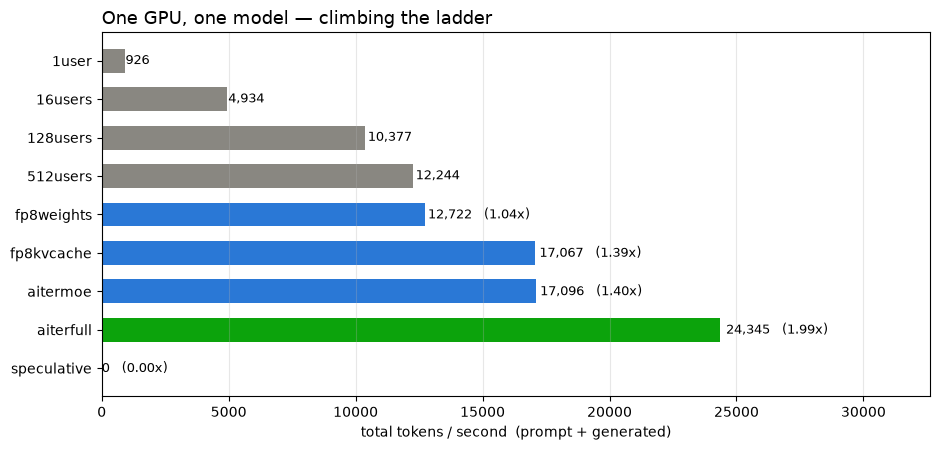

In [66]:
import matplotlib.pyplot as plt

names = [r[0] for r in rows]
vals  = [r[1] for r in rows]
ramp  = [n.endswith("user") or n.endswith("users") for n in names]

plt.figure(figsize=(9.5, 4.6))
colors = ["#898781" if r else "#2a78d6" for r in ramp]
colors[vals.index(max(vals))] = "#0ca30c"
bars = plt.barh(names, vals, color=colors, height=0.62)
base = next((v for n, v in zip(names, vals) if n.startswith("512users")), vals[0])
for i, v in enumerate(vals):
    plt.text(v * 1.01, i, f"{v:,.0f}" + ("" if ramp[i] else f"   ({v/base:.2f}x)"),
             va="center", fontsize=9)
plt.gca().invert_yaxis()
plt.xlim(0, max(vals) * 1.34)
plt.xlabel("total tokens / second  (prompt + generated)")
plt.title("One GPU, one model — climbing the ladder", loc="left", fontsize=13)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 📖 Reading the chart

**Grey bars** are the concurrency ramp — finding the right place to stand.
**Blue bars** are the optimisations, each measured at 128 users and compared to that grey 512-user bar.
**Green** is where we finished.

---

## 🧭 Four things to take home

**1. Benchmark at realistic concurrency.** One request tells you nothing about production.

**2. Read the startup log.** `Maximum concurrency` answers *"how many users can I serve?"* before you
write a single load test.

**3. KV cache is the ceiling.** Right-sizing, FP8 weights and FP8 cache are three ways of raising it.

**4. Change one thing, measure, repeat.** The only way to know *why* something got faster.

---

## 📋 Your production command

```bash
docker run -d --rm --name vllm-server \
    --network host --ipc host \
    --device /dev/kfd --device /dev/dri \
    --group-add video --group-add render \
    --shm-size 16g \
    -e HIP_VISIBLE_DEVICES=0 \
    -e VLLM_ROCM_USE_AITER=1 \
    -v ~/.cache/huggingface:/root/.cache/huggingface \
    --entrypoint '' \
    rocm/vllm:latest \
    vllm serve Qwen/Qwen3-30B-A3B-FP8 \
        --port 8000 \
        --max-model-len 8192 \
        --max-num-seqs 256 \
        --max-num-batched-tokens 8192 \
        --gpu-memory-utilization 0.92 \
        --kv-cache-dtype fp8 \
        --moe-backend aiter \
        --linear-backend aiter \
        --attention-backend ROCM_AITER_UNIFIED_ATTN \
        --speculative-config '{"method":"ngram","num_speculative_tokens":5,"prompt_lookup_max":4}' \
        --enable-auto-tool-choice --tool-call-parser hermes \
        --reasoning-parser qwen3
```

---
## 🔭 What we deliberately skipped

### 🚨 We never checked whether we broke anything

Two changes today were **lossy** — FP8 weights and, more so, the FP8 cache. Speculative decoding
isn't. Quantization is.

Before any of this reaches production: run an accuracy check across 16-bit → FP8 → FP8+FP8-cache and
decide whether the gap is acceptable **for your task**. A 2× speedup you can't defend on quality
isn't a speedup.

*This is the most important cell in the notebook, and it's the one we skipped for time.*

### 🖥️ Anything needing a second GPU

Tensor parallelism, expert parallelism (a natural fit for this MoE), data-parallel replicas,
prefill/decode disaggregation. That's the next talk.

### 🚦 Everything above a single server

We spent this hour making **one** model as fast as it goes. The next question is usually the opposite:
you have several models, and most requests don't need your biggest one.

[**vLLM Semantic Router**](https://github.com/vllm-project/semantic-router) classifies each incoming
request and picks which model should answer it. Trivial question → small fast model. Hard one → the
big reasoning model. Your app keeps calling one OpenAI-compatible endpoint and never knows.

It attacks a cost axis nothing today touched: every knob here made one model cheaper **per token**;
routing stops you spending the expensive model's tokens **at all**. On mixed traffic that's often the
bigger win — and the two stack.

### 📦 Also left out

Triton MoE autotuning · structured outputs (forcing valid JSON) · LoRA hot-swapping · and deliberately
starving the KV cache to watch requests get evicted — the fastest way to learn what a saturated vLLM
server looks like *before* you meet one at 3am.

In [67]:
# Free the GPU.
!cp logs/current.log logs/speculative.log 2>/dev/null; pkill -f 'vllm serve'

---
# 🎉 That's a wrap

You took a default `vllm serve` and climbed a ladder of flags to something several times faster,
on identical hardware.

More importantly, you now know **which questions to ask**:

> *What's my KV cache pool? How many users does that allow? Where on the throughput/latency curve do I
> want to sit? And did that flag actually take effect?*

**Go break something.** 🚀